 t-distribution

In [2]:
'''What proportion of the t-distribution with 18 degrees of freedom falls below -2.10?'''
from scipy.stats import t
result = t.cdf(-2.10, df=18)
print(result)

0.025045202854784173


In [1]:
'''A t-distribution with 20 degrees of freedom is shown in the left panel of Figure 7.4. Estimate the
proportion of the distribution falling above 1.65.'''
from scipy.stats import t
result = 1-t.cdf(1.65, df=20)
print(result)

0.05728041226893965


In [3]:
'''A t-distribution with 2 degrees of freedom is shown in the right panel of Figure 7.4. Estimate the
proportion of the distribution falling more than 3 units from the mean (above or below).'''
'''
With so few degrees of freedom, the t-distribution will give a more notably different value than the
normal distribution. Under a normal distribution, the area would be about 0.003 using the 68-95-
99.7 rule. For a t-distribution with df = 2, the area in both tails beyond 3 units totals 0.0955. This
area is dramatically different than what we obtain from the normal distribution.'''
from scipy.stats import t
result =(1- t.cdf(3, df=2))*2
print(result)

0.095465966266709


In [4]:
from scipy.stats import norm

# Mean and standard deviation for standard normal distribution
mean = 0
std_dev = 1

# Calculate cumulative probability for -3 and +3
prob_below_negative_3 = norm.cdf(-3, loc=mean, scale=std_dev)
prob_above_positive_3 = 1 - norm.cdf(3, loc=mean, scale=std_dev)

# Total proportion falling more than 3 units from the mean
total_proportion = prob_below_negative_3 + prob_above_positive_3

print(total_proportion)

0.0026997960632601965


In [5]:
'''What proportion of the t-distribution with 19 degrees of freedom falls above -1.79 units? Use your
preferred method for finding tail areas.'''
#approve when n is big, the t-distribution and norm-distribution generate very close results. 

from scipy.stats import t
result = 1-t.cdf(-1.79, df=19)
print(result)

0.9552977656658079


In [6]:
from scipy.stats import norm

# Mean and standard deviation for standard normal distribution
mean = 0
std_dev = 1

# Calculate cumulative probability for -3 and +3
proportion = 1 - norm.cdf(-1.79, loc=mean, scale=std_dev)


print(proportion)

0.9632730443012737


In [10]:
'''
We will identify a confidence interval for the average mercury content in dolphin muscle using a
sample of 19 Risso’s dolphins from the Taiji area in Japan. The data are summarized in Figure 7.6.
The minimum and maximum observed values can be used to evaluate whether or not there are clear
outliers.
n x s ¯ minimum maximum
19 4.4 2.3 1.7 9.2

'''
x=4.4
s=2.3
n=19
#Using the summary statistics in Figure 7.6, compute the standard error for the average mercury content in the n = 19 dolphins.
se= s/(n**(1/2))

#When n = 19, what is the appropriate degrees of freedom? Find t⋆df for this degrees of freedom and the confidence level of 95%
#Using statistical software, we find the cutoff where the upper tail is equal to 2.5%: t⋆18 = 2.10. The area below -2.10 will also be equal to 2.5%. That is, 95% of the t-distribution with df = 18 lies within 2.10 units of 0.
from scipy.stats import t

# Degrees of freedom
df = n-1

# Confidence level
confidence_level = 0.95

# Calculate the critical value t, use percent point function*
alpha = 1 - confidence_level
t_star = t.ppf(1 - alpha/2, df)

se, t_star

(0.527656187902292, 2.10092204024096)

In [11]:
'''
Compute and interpret the 95% confidence interval for the average mercury content in Risso’s
dolphins.'''
# we are 95% confident that the average mercury content in dophine is between 3.3 to 5.5  µg/wet gram.
confidence_interval_up=x+t_star*se
confidence_interval_low=x-t_star*se
confidence_interval_up,confidence_interval_low

(5.508564514833451, 3.2914354851665495)

In [15]:
'''
The FDA’s webpage provides some data on mercury content of fish. Based on a sample of 15 croaker
white fish (Pacific), a sample mean and standard deviation were computed as 0.287 and 0.069 ppm
(parts per million), respectively. The 15 observations ranged from 0.18 to 0.41 ppm. We will assume
these observations are independent.
Estimate the standard error of ¯x = 0.287 ppm using the data summaries in Guided Practice 7.10.
If we are to use the t-distribution to create a 90% confidence interval for the actual mean of the
mercury content, identify the degrees of freedom and t⋆df .
'''
from scipy.stats import t

#alpha, df
x_bar=0.287
conficence_interval=0.9
alpha=1-conficence_interval

n=15
df=n-1

#t_star
#Since the goal is a 90% confidence interval, we choose t⋆14 so that the two-tail area is 0.1: t⋆14 = 1.76.
t_star = t.ppf(1 - alpha/2, df)

#se

standard_deviation=0.069
se=standard_deviation/(n**(1/2))

#interval
confidence_interval_up=x_bar+t_star*se
confidence_interval_low=x_bar-t_star*se

df, t_star,se,confidence_interval_up,confidence_interval_low
'''
The 90% confidence interval from Guided Practice 7.12 is 0.256 ppm to 0.318 ppm. Can we say that
90% of croaker white fish (Pacific) have mercury levels between 0.256 and 0.318 ppm?
No, a confidence interval only provides a range of plausible values for a population parameter, 
in this case the population mean. It does not describe what we might observe for individual observations.
'''

(14,
 1.7613101357748562,
 0.01781572339255412,
 0.3183790141874667,
 0.25562098581253323)

In [24]:
'''
Is the typical US runner getting faster or slower over time? We consider this question in the context
of the Cherry Blossom Race, which is a 10-mile race in Washington, DC each spring.
The average time for all runners who finished the Cherry Blossom Race in 2006 was 93.29
minutes (93 minutes and about 17 seconds). We want to determine using data from 100 participants
in the 2017 Cherry Blossom Race whether runners in this race are getting faster or slower, versus
the other possibility that there has been no change.

What are appropriate hypotheses for this context?
'''
#H0=no change  H0=93.29
#Ha~=93.29
'''
When completing a hypothesis test for the one-sample mean, the process is nearly identical to
completing a hypothesis test for a single proportion. First, we find the Z-score using the observed
value, null value, and standard error; however, we call it a T-score since we use a t-distribution for
calculating the tail area. Then we find the p-value using the same ideas we used previously: find
the one-tail area under the sampling distribution, and double it.

'''
'''
The sample mean and sample standard deviation of the sample of 100
runners from the 2017 Cherry Blossom Race are 97.32 and 16.98 minutes, respectively. Recall that
the sample size is 100 and the average run time in 2006 was 93.29 minutes. Find the test statistic
and p-value. What is your conclusion?

'''
from scipy.stats import t
n=100
sample_mean=97.32
population_mean=93.29
sample_standard_deviation=16.98
#To find the test statistic (T-score), we first must determine the standard error:
se=sample_standard_deviation/(n**(1/2))
#Now we can compute the T-score using the sample mean (97.32), null value (93.29), and SE:
t_score=(sample_mean-population_mean)/se

# Calculate cumulative probability
one_tail_area = 1 - t.cdf(t_score, df=n-1)
p_value=one_tail_area*2

se,t_score,one_tail_area,p_value
'''Because the p-value is smaller than 0.05, we reject the null hypothesis. That is, the data provide
strong evidence that the average run time for the Cherry Blossom Run in 2017 is different than
the 2006 average. Since the observed value is above the null value and we have rejected the null
hypothesis, we would conclude that runners in the race were slower on average in 2017 than in 2006.'''

(1.698, 2.373380447585387, 0.009778331619634373, 0.019556663239268746)

In [27]:
'''
UCLA Bookstore price − Amazon price
It is important that we always subtract using a consistent order; here Amazon prices are always
subtracted from UCLA prices. The first difference shown in Figure 7.8 is computed as 47.97 −
47.45 = 0.52. Similarly, the second difference is computed as 14.26 − 13.55 = 0.71, and the third
is 13.50 − 12.53 = 0.97. A histogram of the differences is shown in Figure 7.9. Using differences
between paired observations is a common and useful way to analyze paired data.
nalyze a paired data set, we simply analyze the differences. We can use the same tdistribution techniques we applied in Section 7.1.
ndiff x¯diff sdiff
68 3.58 13.42
Figure 7.10: Summary statistics for the 68 price differences.
EXAMPLE 7.17
Set up a hypothesis test to determine whether, on average, there is a difference between Amazon’s
price for a book and the UCLA bookstore’s price. Also, check the conditions for whether we can
move forward with the test using the t-distribution.
H0: µdiff = 0. There is no difference in the average textbook price.
HA: µdiff ̸= 0. There is a difference in average prices.
'''
from scipy.stats import t
n=68
x_bar_diff=3.58
mean=0
sdiff=13.42
se=sdiff/(n**(1/2))
t_score=(sample_mean-population_mean)/se
t_score=(x_bar_diff-mean)/se
one_tail_area = 1 - t.cdf(t_score, df=n-1)
p_value=one_tail_area*2
se,t_score,one_tail_area,p_value
'''
Because the p-value is less than 0.05, we reject the null hypothesis. Amazon prices are, on average,
lower than the UCLA Bookstore prices for UCLA courses
'''

(1.6274140439937943,
 2.1998089626991395,
 0.015637069605905052,
 0.031274139211810104)

In [33]:
'''The summary statistics in Figure 7.15 may be useful for this Guided Practice.13
(a) What is the point estimate of the population difference, µn − µs?
(b) Compute the standard error of the point estimate from part (a).
smoker nonsmoker
mean 6.78 7.18
st. dev. 1.43 1.60
samp. size 50 100'''
from scipy.stats import t
#H0=0
#Ha~=0
Mean_diff=6.78-7.18
stdv1=1.43
stdv2=1.60
n1=50
n2=100
se= (stdv1**2/n1+stdv2**2/n2)**(1/2)
'''Complete the hypothesis test started. Use a significance
level of α = 0.05. For reference, ¯xn − x¯s = 0.40, SE = 0.26, and the sample sizes were nn = 100
and ns = 50.
'''
df=50-1
Mean_0=0
t_score=(Mean_diff-Mean_0)/se
p_value=t.cdf(t_score, df=df)*2
se,t_score,df,p_value
'''The p-value is larger than the significance value, 0.05, so we do not reject the null hypothesis. There
is insufficient evidence to say there is a difference in average birth weight of newborns from North
Carolina mothers who did smoke during pregnancy and newborns from North Carolina mothers who
did not smoke during pregnancy.'''

'The p-value is larger than the significance value, 0.05, so we do not reject the null hypothesis. There\nis insufficient evidence to say there is a difference in average birth weight of newborns from North\nCarolina mothers who did smoke during pregnancy and newborns from North Carolina mothers who\ndid not smoke during pregnancy.'

In [40]:
'''An instructor decided to run two slight variations of the same exam. Prior to passing out the
exams, she shuffled the exams together to ensure each student received a random version. Summary
statistics for how students performed on these two exams are shown in Figure 7.16. Anticipating
complaints from students who took Version B, she would like to evaluate whether the difference
observed in the groups is so large that it provides convincing evidence that Version B was more
difficult (on average) than Version A.
Version n x s ¯ min max
A 30 79.4 14 45 100
B 27 74.1 20 32 100
Construct hypotheses to evaluate whether the observed difference in sample means, ¯xA − x¯B = 5.3,
is due to chance. We will later evaluate these hypotheses using α = 0.01'''
from scipy.stats import t
#H0=0
#Ha~=0
mean_a=79.4
mean_b=74.1
mean_diff=mean_a-mean_b
mean_0=0
na=30
nb=27
df=27-1
stdvA=14
stdvB=20
se=((stdvA**2)/na+(stdvB**2)/nb)**(1/2)
t_value=(mean_diff-Mean_0)/se
p_value=(1-t.cdf(t_value, df=df))*2
se,df,t_value,p_value
#p_value is more than alpha 0.01.we can not reject null hypothesis. so there is no enough evedence that B test is harder than A. 

(4.620405625932441, 26, 1.1470854355845483, 0.261792896337262)

In [44]:
'''
7.23 The benefits of pooling the standard deviation are realized through obtaining a better estimate
of the standard deviation for each group and using a larger degrees of freedom parameter for the
t-distribution. Both of these changes may permit a more accurate model of the sampling distribution
of ¯x1 − x¯2, if the standard deviations of the two groups are indeed equal.
6th 13th Diff.
x¯ 128,385 126,550 1,835
s 7,259 7,664 1,176
n 10 10 10

(a) Are there any underlying structures in these data that should be considered in an analysis? Explain.
s are similar
(b) What are the hypotheses for evaluating whether the number of people out on Friday the 6th is different
than the number out on Friday the 13th?
H0=0
Ha~=0
(c) Check conditions to carry out the hypothesis test from part (b).
(d) Calculate the test statistic and the p-value.
(e) What is the conclusion of the hypothesis test?
(f) Interpret the p-value in this context.
(g) What type of error might have been made in the conclusion of your test? Explain.
'''
#Paired observations
from scipy.stats import t
n=10
df=n-1
x_diff=1835
x0=0
s=1176
se=s/(n**(1/2))
t_stats=(x_diff-x0)/se
p_value=(1-t.cdf(t_stats, df=df))*2
se,t_stats,p_value

#p_value very small, so we are confident to reject nall hipotheses, so the traffic on 6th is higher than 13 th

(371.8838528358014, 4.934336314973619, 0.0008085064554024246)

In [49]:
'''
EXAMPLE 7.32
The researchers would like to run the clinical trial on patients with systolic blood pressures between
140 and 180 mmHg. Suppose previously published studies suggest that the standard deviation of the
patients’ blood pressures will be about 12 mmHg and the distribution of patient blood pressures will
be approximately symmetric.26 If we had 100 patients per group, what would be the approximate
standard error for ¯xtrmt − x¯ctrl?

Determining a proper sample size
We want to avoid this situation, so we need to determine an appropriate sample size to ensure we can
be pretty confident that we’ll detect any effects that are practically important. As mentioned earlier,
a change of 3 mmHg was deemed to be the minimum difference that was practically important. As a
first step, we could calculate power for several different sample sizes. For instance, let’s try 500
patients per group.

GUIDED PRACTICE 7.36
Calculate the power to detect a change of -3 mmHg when using a sample size of 500 per group.27
(a) Determine the standard error (recall that the standard deviation for patients was expected to
be about 12 mmHg).
(b) Identify the null distribution and rejection regions.
(c) Identify the alternative distribution when µtrmt − µctrl = −3.
(d) Compute the probability we reject the null hypothesis.
'''
from scipy.stats import t

stdv=12
n=500
df=n-1
x_bar_diff_0=0
alpha=0.05

#(a) Determine the standard error (recall that the standard deviation for patients was expected to
be about 12 mmHg).
se=((stdv**2)/500 + (stdv**2)/500 )**(1/2)

#(b) Identify the null distribution and rejection regions.
t_star = t.ppf(1 - alpha/2, df)

rejection_regions_up=x_bar_diff_0+t_star*se
rejection_regions_low=x_bar_diff_0-t_star*se

#(c) Identify the alternative distribution when µtrmt − µctrl = −3.
x_bar_diff_a=-3
t_reject=(rejection_regions_low-x_bar_diff_a)/se

#(d) Compute the probability we reject the null hypothesis
p_value_reject=t.cdf(t_reject, df=df)

#H0=0

se,t_star,rejection_regions_up,rejection_regions_low,t_reject,p_value_reject

(0.758946638440411,
 1.9647293909876649,
 1.4911247667351641,
 -1.4911247667351641,
 1.9881176842228097,
 0.9763276931344662)

In [ ]:
'''
What sample size will lead to a power of 80%? Use α = 0.05.'''

In [53]:
'''Suppose the targeted power was 90% and we were using α = 0.01. How many standard errors should
separate the centers of the null and alternative distribution, where the alternative distribution is
centered at the minimum effect size of interest?'''
from scipy.stats import norm
alpha=0.01
power=0.9
z_0 = norm.ppf(alpha/2)
z_a = norm.ppf(power)
between_0_a=-z_0+z_a
z_0,z_a,between_0_a

(-2.575829303548901, 1.2815515655446004, 3.857380869093501)

Bootstrapping

Bootstrap mean: 11.233222222222222
95% Confidence Interval: [7.333333333333333, 15.0]


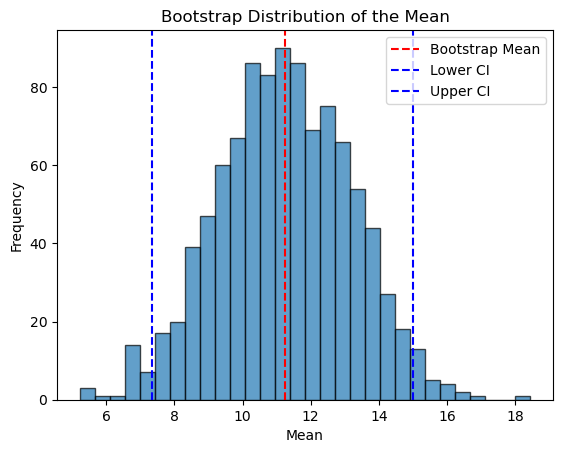

'\n\n### Explanation\n\n1. **Data**: We start with an array `data` containing our original sample.\n2. **Resampling**: We repeatedly generate new samples (`bootstrap_sample`) by randomly selecting elements from `data` with replacement.\n3. **Statistic Calculation**: For each resample, we calculate the mean (`bootstrap_mean`).\n4. **Store Results**: We store these means in `bootstrap_means`.\n5. **Confidence Intervals**: After generating many bootstrapped means, we can calculate the confidence interval by finding percentiles.\n\nThis simple example illustrates how bootstrapping can be used to estimate the mean and its confidence interval from a small dataset without making strong assumptions about its underlying distribution.\n\nFeel free to ask if you have any questions or need further clarification!\n'

In [56]:
'''
Absolutely! Let's dive into bootstrapping in statistics.

### What is Bootstrapping?

Bootstrapping is a resampling technique used to estimate the distribution of a statistic (like the mean, variance, or median) by sampling with replacement from the original dataset. This allows you to approximate the sampling distribution of the statistic without making strong assumptions about the underlying population.

### Why Use Bootstrapping?

- **Non-parametric**: It doesn't assume a specific parametric form for the population distribution.
- **Versatile**: Can be used for a variety of statistics.
- **Practical**: Useful when dealing with small sample sizes where traditional methods might not be reliable.

### Steps to Perform Bootstrapping

Let's break down the process step-by-step:

1. **Original Sample**:
   - Start with your original data sample of size  n .

2. **Resampling**:
   - Randomly draw n  observations from your original sample with replacement. This means some data points may be selected more than once while others may not be selected at all.

3. **Statistic Calculation**:
   - Calculate the statistic of interest (e.g., mean, median) for this resampled dataset.

4. **Repeat**:
   - Repeat steps 2 and 3 many times (typically 1,000 or more). Each repetition is called a bootstrap sample and gives you a bootstrap replicate of the statistic.

5. **Analyze Bootstrap Replicates**:
   - Use the distribution of these replicates to estimate properties of the statistic (e.g., confidence intervals, standard errors).

### Example: Bootstrapping the Mean

Let's go through an example using Python code to illustrate bootstrapping.

#### Step-by-Step Code Example
'''
import numpy as np
import matplotlib.pyplot as plt

# Original data sample
data = np.array([3, 7, 8, 5, 12, 14, 21, 13, 18])

# Number of bootstrap samples
n_iterations = 1000
n_size = len(data)

# Array to store bootstrap means
bootstrap_means = []

# Perform bootstrapping
for _ in range(n_iterations):
    # Generate a bootstrap sample by sampling with replacement
    bootstrap_sample = np.random.choice(data, size=n_size, replace=True)
    # Calculate the mean of the bootstrap sample
    bootstrap_mean = np.mean(bootstrap_sample)
    # Store the result
    bootstrap_means.append(bootstrap_mean)

# Convert list to array for convenience
bootstrap_means = np.array(bootstrap_means)

# Calculate confidence intervals (e.g., 95%)
alpha = 0.05
lower_bound = np.percentile(bootstrap_means, alpha/2*100)
upper_bound = np.percentile(bootstrap_means, (1-alpha/2)*100)

print(f'Bootstrap mean: {np.mean(bootstrap_means)}')
print(f'95% Confidence Interval: [{lower_bound}, {upper_bound}]')

# Plotting the bootstrap distribution
plt.hist(bootstrap_means, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(x=np.mean(bootstrap_means), color='red', linestyle='--', label='Bootstrap Mean')
plt.axvline(x=lower_bound, color='blue', linestyle='--', label='Lower CI')
plt.axvline(x=upper_bound, color='blue', linestyle='--', label='Upper CI')
plt.title('Bootstrap Distribution of the Mean')
plt.xlabel('Mean')
plt.ylabel('Frequency')
plt.legend()
plt.show()

'''
### Explanation

1. **Data**: We start with an array `data` containing our original sample.
2. **Resampling**: We repeatedly generate new samples (`bootstrap_sample`) by randomly selecting elements from `data` with replacement.
3. **Statistic Calculation**: For each resample, we calculate the mean (`bootstrap_mean`).
4. **Store Results**: We store these means in `bootstrap_means`.
5. **Confidence Intervals**: After generating many bootstrapped means, we can calculate the confidence interval by finding percentiles.

This simple example illustrates how bootstrapping can be used to estimate the mean and its confidence interval from a small dataset 
without making strong assumptions about its underlying distribution.

Feel free to ask if you have any questions or need further clarification!
'''

In [57]:
bootstrap_sample = np.random.choice(data, size=n_size, replace=True)
bootstrap_sample

array([ 7, 13,  7,  7, 14,  7, 21, 12,  8])

In [ ]:
'''
Sure! Let's go through an intuitive explanation of why bootstrapping works.

### Understanding Bootstrapping Intuitively

Imagine you have a small dataset, and you want to understand something about the entire population that this data represents, like the average height of people in a city. However, you only have data from 10 people. Traditional statistical methods might require assumptions about the population's distribution (e.g., assuming it's normally distributed), but bootstrapping offers a more flexible approach.

Here’s how bootstrapping helps:

1. **Original Sample as a Proxy**:
   - Your original sample is like a miniature version of the population. While it doesn’t capture every detail, it contains valuable information about the population's characteristics.
   
2. **Resampling with Replacement**:
   - By resampling with replacement, you're creating many new "mini-datasets" that are similar to your original sample. Each resample can include repeated values because you're sampling with replacement.
   - Think of it like repeatedly shaking a bag filled with your original data and drawing out observations one at a time, putting each one back before drawing again.

3. **Simulating Variability**:
   - Each resampled dataset will be slightly different due to random selection. This variability mimics the natural variations you'd expect if you were able to take multiple samples from the actual population.
   - Essentially, bootstrapping generates many possible scenarios of what your data could look like if you kept sampling from the population.

4. **Estimating Distribution**:
   - By calculating the statistic of interest (e.g., mean, median) for each resample, you build up a distribution of these statistics.
   - This distribution gives you a sense of how much the statistic might vary from sample to sample, which helps estimate its true value and uncertainty.

### Why It Works

- **Captures Sample Variability**: Bootstrapping leverages the variability within your sample to make inferences about the population. Even though each resample isn't identical to others or to the original sample, together they provide a good approximation of what you'd expect from multiple samples of the population.
  
- **Non-parametric Nature**: Unlike traditional methods that rely on specific assumptions (like normality), bootstrapping doesn't assume any particular distribution for your data. It's purely based on the observed data, making it robust and versatile.

- **Large Number of Resamples**: By taking a large number of resamples (typically 1,000 or more), you ensure that the resulting distribution of your statistic is stable and reliable. This large-scale simulation helps smooth out random fluctuations and provides a clear picture of the underlying statistical properties.

### Visualization

Imagine you have a small deck of cards representing your dataset:

1. **Draw Samples**: You shuffle the deck and draw cards one by one with replacement (putting each card back before drawing again). Each shuffle gives you a new set of cards that resembles but isn't identical to your original deck.
   
2. **Calculate Statistics**: For each new set, calculate something like the average value on the cards.

3. **Repeat Many Times**: After repeating this process many times, you'll have a collection of average values from all your shuffles.

4. **Analyze Results**: The spread and center of these average values give you insights into what the true average might be and how much it could vary if you drew different samples from the population.

In summary, bootstrapping works by using the limited information available in your sample to simulate many possible versions of what your sample could look like if drawn repeatedly from the population. This allows you to estimate statistical properties and their uncertainties without relying on strict assumptions about the underlying distribution.

'''